# **Activate GPU**

In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Add Important Libraries**

In [2]:
import os
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout,Rescaling,RandomFlip,RandomRotation,RandomZoom,BatchNormalization,GlobalAveragePooling2D,RandomContrast,RandomBrightness,Activation


from tensorflow.keras.initializers import HeNormal
from tensorflow.keras import layers
from tensorflow.data import AUTOTUNE
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping

from tensorflow.keras.models import load_model

# **Add Google Drive**

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **Add Kaggle API**

In [ ]:
from google.colab import files
files.upload()



# **Add Dataset From Kaggle**

In [ ]:
!mkdir -p ~/.kaggle

!mv kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d rizwan123456789/potato-disease-leaf-datasetpld

!unzip -q potato-disease-leaf-datasetpld.zip -d ./data

!rm potato-disease-leaf-datasetpld.zip

!ls ./data

# **Set Data Directory**

In [31]:
data_dir = "/content/data/PLD_3_Classes_256"

train_dir = os.path.join(data_dir, "Training")
val_dir   = os.path.join(data_dir, "Validation")
test_dir  = os.path.join(data_dir, "Testing")

# **Split The Data into Train and Test Set**

In [32]:
train_ds=keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(150,150),
    batch_size=64,
    shuffle=True,
    color_mode="rgb",
    label_mode="categorical",
    labels="inferred"
)
val_ds=keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(150,150),
    batch_size=64,
    shuffle=False,
    color_mode="rgb",
    label_mode="categorical",
    labels="inferred"
)
test_ds=keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(150,150),
    batch_size=64,
    shuffle=False,
    color_mode="rgb",
    label_mode="categorical",
    labels="inferred"
)

Found 3251 files belonging to 3 classes.
Found 416 files belonging to 3 classes.
Found 405 files belonging to 3 classes.


In [33]:
train_ds_resnet=keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=64,
    shuffle=True,
    color_mode="rgb",
    label_mode="categorical",
    labels="inferred"
)
val_ds_resnet=keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224,224),
    batch_size=64,
    shuffle=False,
    color_mode="rgb",
    label_mode="categorical",
    labels="inferred"
)
test_ds_resnet=keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224,224),
    batch_size=64,
    shuffle=False,
    color_mode="rgb",
    label_mode="categorical",
    labels="inferred"
)

Found 3251 files belonging to 3 classes.
Found 416 files belonging to 3 classes.
Found 405 files belonging to 3 classes.


## **Find The Class Name**

In [34]:
class_names=train_ds.class_names
print(class_names)

['Early_Blight', 'Healthy', 'Late_Blight']


# **Perform Cache and Autotune for Fast Processing**

In [13]:
train_ds=train_ds.cache().shuffle(2500).prefetch(buffer_size=AUTOTUNE)
test_ds=test_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds=val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [14]:
train_ds_resnet=train_ds_resnet.cache().shuffle(2500).prefetch(buffer_size=AUTOTUNE)
test_ds_resnet=test_ds_resnet.cache().prefetch(buffer_size=AUTOTUNE)
val_ds_resnet=val_ds_resnet.cache().prefetch(buffer_size=AUTOTUNE)

# **Perform Data Augmentation to Reduce Overfitting**

In [15]:
data_augmentation = keras.Sequential(
    [
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.2),
    ]
)

# **Load The Models**

In [16]:
model_cnn = load_model(
    "/content/drive/MyDrive/potato_cnn_full_model.h5"
)

In [23]:
cnn_loss,cnn_acc=model_cnn.evaluate(test_ds)
print()
print()
print("Accuracy: ",cnn_acc)
print()
print("Loss: ",cnn_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9737 - loss: 0.0955


Accuracy:  0.980246901512146

Loss:  0.07702891528606415


In [17]:
model_resnet = load_model(
    "/content/drive/MyDrive/potato_resnet_model.h5"
)

In [24]:
resnet_loss,resnet_acc=model_resnet.evaluate(test_ds_resnet)
print()
print()
print("Accuracy: ",resnet_acc)
print()
print("Loss: ",resnet_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 350ms/step - accuracy: 0.9762 - loss: 0.0812


Accuracy:  0.9827160239219666

Loss:  0.06373567134141922


In [18]:
model_vgg = load_model(
    "/content/drive/MyDrive/potato_vgg_full.h5"
)

In [25]:
vgg_loss,vgg_acc=model_vgg.evaluate(test_ds_resnet)
print()
print()
print("Accuracy: ",vgg_acc)
print()
print("Loss: ",vgg_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 773ms/step - accuracy: 0.9837 - loss: 0.0642


Accuracy:  0.9851852059364319

Loss:  0.0550762414932251


In [19]:
model_densenet = load_model(
    "/content/drive/MyDrive/potato_densenet_full_model.h5"
)

In [26]:
densenet_loss,densenet_acc=model_densenet.evaluate(test_ds_resnet)
print()
print()
print("Accuracy: ",densenet_acc)
print()
print("Loss: ",densenet_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 440ms/step - accuracy: 0.8674 - loss: 0.3485


Accuracy:  0.8172839283943176

Loss:  0.4228265881538391


# **Compare**

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def evaluate_model(model, test_ds, model_name):
    y_true = []
    y_pred = []

    for x_batch, y_batch in test_ds:
        y_true.extend(np.argmax(y_batch.numpy(), axis=1))

        probs = model.predict(x_batch, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }


In [38]:

results = []

results.append(evaluate_model(model_cnn, test_ds, "Custom CNN"))
results.append(evaluate_model(model_vgg, test_ds_resnet, "VGG16"))
results.append(evaluate_model(model_resnet, test_ds_resnet, "ResNet50"))
results.append(evaluate_model(model_densenet, test_ds_resnet, "DenseNet121"))

total_df = pd.DataFrame(results)
total_df


,Model,Accuracy,Precision,Recall,F1-score
0,Custom CNN,0.980247,0.980745,0.980247,0.980259
1,VGG16,0.985185,0.985727,0.985185,0.985263
2,ResNet50,0.982716,0.983521,0.982716,0.982818
3,DenseNet121,0.817284,0.825562,0.817284,0.813858


In [39]:
total_df["Loss"]=cnn_loss,vgg_loss,resnet_loss,densenet_loss

In [40]:
total_df

,Model,Accuracy,Precision,Recall,F1-score,Loss
0,Custom CNN,0.980247,0.980745,0.980247,0.980259,0.077029
1,VGG16,0.985185,0.985727,0.985185,0.985263,0.055076
2,ResNet50,0.982716,0.983521,0.982716,0.982818,0.063736
3,DenseNet121,0.817284,0.825562,0.817284,0.813858,0.422827


In [41]:
df_new = total_df.copy()
df_new.iloc[:, 1:] = (df_new.iloc[:, 1:] * 100).round(2)
df_new

,Model,Accuracy,Precision,Recall,F1-score,Loss
0,Custom CNN,98.02,98.07,98.02,98.03,7.70
1,VGG16,98.52,98.57,98.52,98.53,5.51
2,ResNet50,98.27,98.35,98.27,98.28,6.37
3,DenseNet121,81.73,82.56,81.73,81.39,42.28


In [42]:
df_new.to_csv("Potato Disease.csv",index=False)

In [44]:
df=pd.read_csv("/content/Potato Disease.csv")
df

,Model,Accuracy,Precision,Recall,F1-score,Loss
0,Custom CNN,98.02,98.07,98.02,98.03,7.70
1,VGG16,98.52,98.57,98.52,98.53,5.51
2,ResNet50,98.27,98.35,98.27,98.28,6.37
3,DenseNet121,81.73,82.56,81.73,81.39,42.28


# **Performance Vizualization**

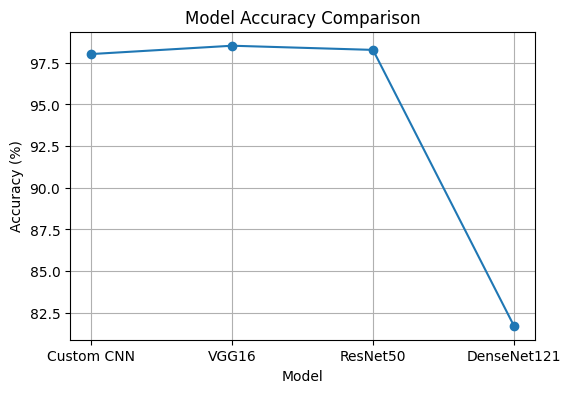

In [45]:
plt.figure(figsize=(6, 4))
plt.plot(df["Model"], df["Accuracy"], marker='o')
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

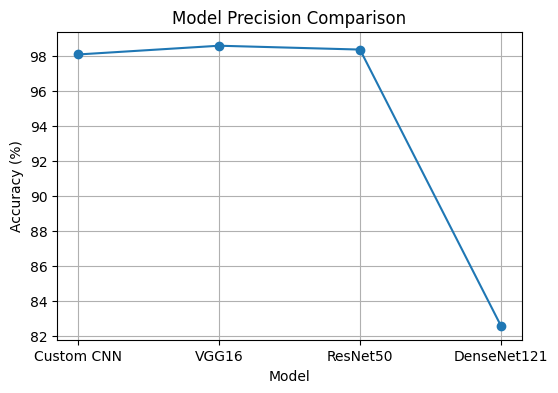

In [46]:

plt.figure(figsize=(6, 4))
plt.plot(df["Model"],df["Precision"], marker='o')
plt.title("Model Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

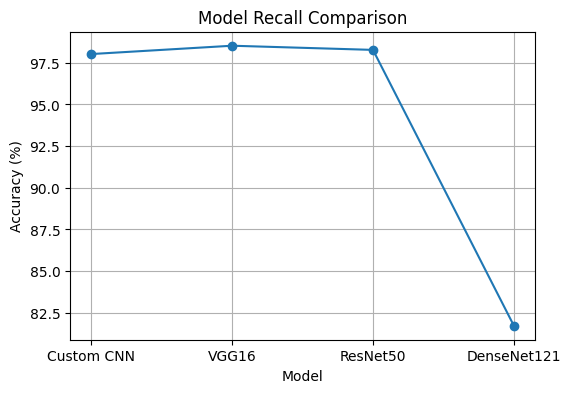

In [47]:

plt.figure(figsize=(6, 4))
plt.plot(df["Model"],df["Recall"], marker='o')
plt.title("Model Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

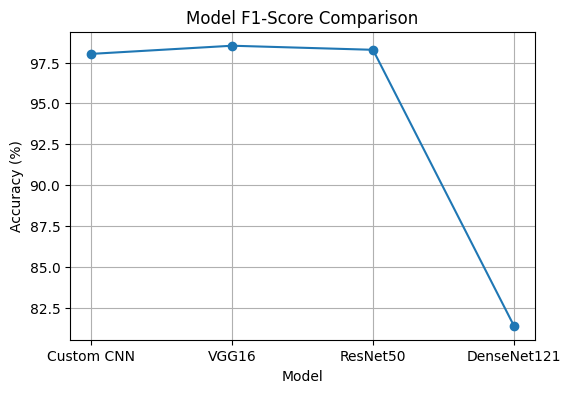

In [48]:

plt.figure(figsize=(6, 4))
plt.plot(df["Model"],df["F1-score"], marker='o')
plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

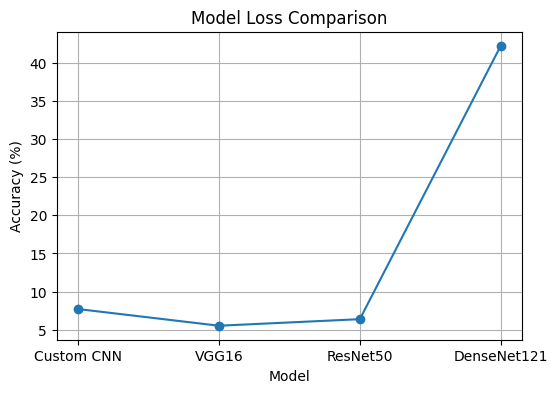

In [49]:
plt.figure(figsize=(6, 4))
plt.plot(df["Model"],df["Loss"], marker='o')
plt.title("Model Loss Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

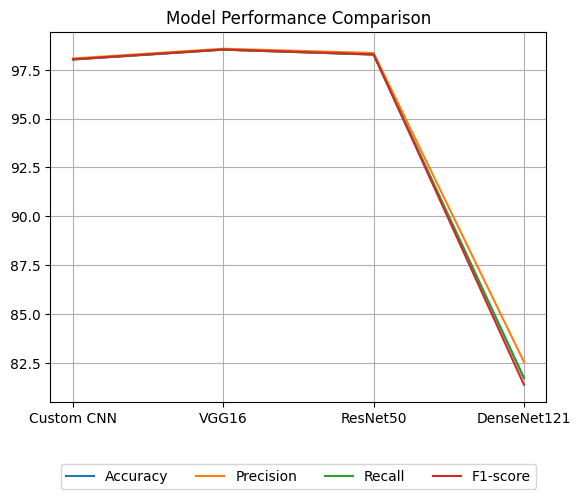

<Figure size 600x400 with 0 Axes>

In [51]:
fig, ax = plt.subplots()
plt.title("Model Performance Comparison")
plt.figure(figsize=(6, 4))
ax.plot(df["Model"], df["Accuracy"], label="Accuracy")
ax.plot(df["Model"], df["Precision"], label="Precision")
ax.plot(df["Model"], df["Recall"], label="Recall")
ax.plot(df["Model"], df["F1-score"], label="F1-score")

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
ax.grid(True)


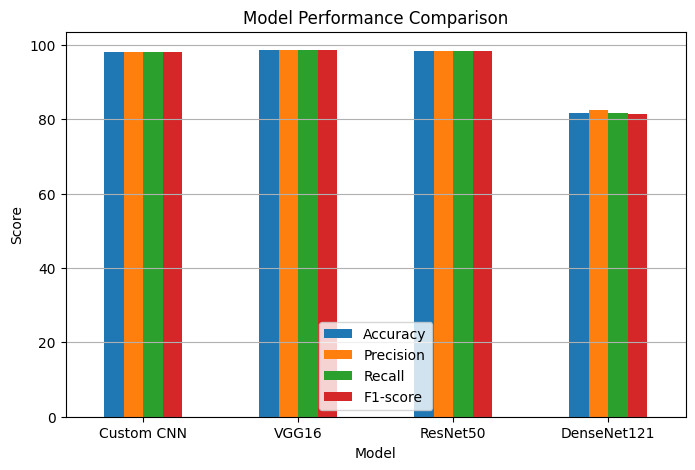

In [52]:
df.set_index("Model")[["Accuracy","Precision","Recall","F1-score"]].plot(
    kind="bar", figsize=(8,5)
)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.grid(axis="y")
